# GenZ-LIO cho người mới bắt đầu

**Mục tiêu của notebook này:** biến paper **“GenZ-LIO: Generalizable LiDAR-Inertial Odometry Beyond Indoor–Outdoor Boundaries”** thành một tài liệu học có thể *đọc hiểu dần từng lớp*, có minh hoạ, code mô phỏng, và các biểu đồ tóm tắt thí nghiệm.

## Notebook này giúp bạn nắm được gì?
- LiDAR-Inertial Odometry (LIO) là gì.
- Vì sao chuyển cảnh **indoor ↔ outdoor** làm nhiều hệ LIO yếu đi.
- 3 ý tưởng cốt lõi của **GenZ-LIO**:
  1. **Scale-aware adaptive voxelization**
  2. **Hybrid-metric state update**
  3. **Voxel-pruned correspondence search**
- Ý nghĩa của các công thức chính trong paper.
- Thông điệp thực nghiệm: **vì sao hệ này vừa ổn định vừa tiết kiệm tính toán**.

> **Lưu ý quan trọng:** notebook này dùng nhiều **mô phỏng 2D đồ chơi** để giải thích trực giác. Nó **không phải** là bản cài đặt đầy đủ của hệ LIO 3D trong paper.  
> Mục tiêu ở đây là: **hiểu thật chắc ý tưởng**, rồi sau đó bạn mới quay lại paper gốc và code thật.

## Bản đồ của paper

Paper đi theo luồng rất rõ:

1. **Bài toán**  
   LIO thường nhạy với:
   - thay đổi **scene scale** (không gian chật ↔ không gian rộng),
   - thay đổi **cấu trúc hình học cục bộ** (nhiều mặt phẳng ↔ ít mặt phẳng),
   - chi phí **correspondence search**.

2. **Ý tưởng tổng thể của GenZ-LIO**
   - Tự ước lượng scene scale bằng **scale indicator**.
   - Điều chỉnh **voxel size** bằng một bộ điều khiển kiểu **PD + gain scheduling**.
   - Kết hợp **point-to-plane** và **point-to-point** trong bước cập nhật trạng thái.
   - Cắt bớt phép dò correspondence bằng **voxel pruning**.

3. **Thực nghiệm**
   - Benchmark trên nhiều bộ dữ liệu indoor, outdoor, transitional.
   - Ablation cho từng module.

## 5 claim chính của paper
1. Hệ đạt độ chính xác cạnh tranh trên indoor, outdoor, và transitional.
2. Adaptive voxelization giúp **ổn định + tiết kiệm tài nguyên** khi scene scale thay đổi.
3. Gain scheduling giúp **tracking setpoint tốt hơn**, giảm dao động và overshoot.
4. Hybrid metric giúp giảm **degeneracy** khi ràng buộc mặt phẳng không đủ.
5. Voxel-pruned search giúp giảm **thời gian correspondence search**.

In [1]:
import math
import warnings
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches
from IPython.display import display

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.unicode_minus": False,
    "font.size": 11,
})

# ---------- Helper functions ----------

def voxelize_2d(points, voxel_size):
    # Simple 2D voxelization used only for intuition demos.
    shift = points.min(axis=0, keepdims=True)
    vox = np.floor((points - shift) / voxel_size).astype(int)
    _, idx = np.unique(vox, axis=0, return_index=True)
    return points[np.sort(idx)]

def make_scaled_scene(scale, n=None, noise=0.03, seed=0):
    # Synthetic 2D scan for intuition.
    # - small scale: narrow corridor-like geometry
    # - medium scale: larger hallway/intersection
    # - large scale: open outdoor-like geometry
    rng = np.random.default_rng(seed)
    if n is None:
        n = 2500 if scale < 20 else 1200

    if scale < 12:
        length = scale + 4
        width = 2.0 + 0.12 * scale
        n_side = n // 3
        x1 = rng.uniform(0, length, n_side)
        y1 = np.full(n_side, width / 2) + rng.normal(0, noise, n_side)

        x2 = rng.uniform(0, length, n_side)
        y2 = np.full(n_side, -width / 2) + rng.normal(0, noise, n_side)

        y3 = rng.uniform(-width / 2, width / 2, n - 2 * n_side)
        x3 = np.full(n - 2 * n_side, length) + rng.normal(0, noise, n - 2 * n_side)

        pts = np.column_stack([
            np.concatenate([x1, x2, x3]),
            np.concatenate([y1, y2, y3]),
        ])
    elif scale < 20:
        length = scale + 4
        width = 4.0 + 0.15 * (scale - 12)
        n_side = n // 4

        x1 = rng.uniform(0, length, n_side)
        y1 = np.full(n_side, width / 2) + rng.normal(0, noise, n_side)

        x2 = rng.uniform(0, length, n_side)
        y2 = np.full(n_side, -width / 2) + rng.normal(0, noise, n_side)

        y3 = rng.uniform(-width / 2, width / 2, n_side)
        x3 = np.full(n_side, length) + rng.normal(0, noise, n_side)

        t = rng.uniform(0, 1, n - 3 * n_side)
        x4 = length * 0.6 + (scale * 0.3) * t + rng.normal(0, noise, len(t))
        y4 = width * 0.2 + (scale * 0.3) * t + rng.normal(0, noise, len(t))

        pts = np.column_stack([
            np.concatenate([x1, x2, x3, x4]),
            np.concatenate([y1, y2, y3, y4]),
        ])
    else:
        angles = rng.uniform(-np.pi * 0.8, np.pi * 0.8, n)
        radii = rng.uniform(scale * 0.5, scale, n)
        x = radii * np.cos(angles) + rng.normal(0, noise * 2, n)
        y = radii * np.sin(angles) + rng.normal(0, noise * 2, n)

        k = max(1, n // 10)
        x2 = rng.uniform(scale * 0.2, scale * 0.9, k)
        y2 = np.full(k, scale * 0.15) + rng.normal(0, noise * 2, k)

        pts = np.column_stack([
            np.concatenate([x, x2]),
            np.concatenate([y, y2]),
        ])
    return pts

def moving_average(x, w):
    x = np.asarray(x, float)
    if w <= 1:
        return x.copy()
    out = np.empty_like(x, dtype=float)
    for i in range(len(x)):
        lo = max(0, i - w + 1)
        out[i] = x[lo:i+1].mean()
    return out

def draw_system_overview():
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 2)
    ax.axis("off")

    blocks = [
        (0.3, 0.4, 2.2, 1.0, "1) Preprocess\n(IMU propagate + deskew)", "#dfe8f3"),
        (3.0, 0.4, 3.0, 1.0, "2) Scale-aware\nadaptive voxelization", "#e7f4df"),
        (6.5, 0.4, 3.2, 1.0, "3) Hybrid-metric\nstate update in ESIKF", "#f7e2d9"),
        (10.1, 0.4, 1.4, 1.0, "4) Map\nupdate", "#efe2f9"),
    ]

    for x, y, w, h, text, color in blocks:
        rect = patches.FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            facecolor=color, edgecolor="black", linewidth=1.2
        )
        ax.add_patch(rect)
        ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=11)

    for x1, x2 in [(2.5, 3.0), (6.0, 6.5), (9.7, 10.1)]:
        ax.annotate("", xy=(x2, 0.9), xytext=(x1, 0.9),
                    arrowprops=dict(arrowstyle="->", lw=2))

    ax.text(1.4, 1.72, "LiDAR scan + IMU", ha="center", fontsize=10)
    ax.text(4.5, 1.72, "scene scale → setpoint → voxel size", ha="center", fontsize=10)
    ax.text(8.1, 1.72, "point-to-plane + point-to-point", ha="center", fontsize=10)
    ax.text(10.8, 1.72, "voxel map", ha="center", fontsize=10)
    plt.show()

def line_jacobian_2d(point, normal=np.array([0.0, 1.0])):
    # Jacobian of 2D point-to-line residual wrt [tx, ty, theta].
    px, py = point
    nx, ny = normal
    return np.array([nx, ny, -nx * py + ny * px], float)

def point_jacobian_vec_2d(point):
    # Jacobian of 2D point-to-point vector residual wrt [tx, ty, theta].
    px, py = point
    return np.array([[1, 0, -py],
                     [0, 1,  px]], float)

def gaussian_pdf(x, mu, sigma):
    return (1.0 / (sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# ----- 2D analog of correspondence search -----

def point_to_rect_dist(q, cell):
    i, j = cell
    x, y = q
    dx = 0 if i <= x <= i + 1 else min(abs(x - i), abs(x - (i + 1)))
    dy = 0 if j <= y <= j + 1 else min(abs(y - j), abs(y - (j + 1)))
    return math.hypot(dx, dy)

def gen_grid_map(num_cells=20, occupancy=0.35, pts_range=(10, 40), seed=0):
    rng = np.random.default_rng(seed)
    cells = {}
    half = num_cells // 2
    for i in range(-half, half):
        for j in range(-half, half):
            if rng.random() < occupancy:
                n = int(rng.integers(pts_range[0], pts_range[1] + 1))
                pts = np.column_stack([
                    rng.uniform(i, i + 1, n),
                    rng.uniform(j, j + 1, n),
                ])
                cells[(i, j)] = pts
    return cells

def brute_force_search_9(cells, q):
    i, j = math.floor(q[0]), math.floor(q[1])
    best = np.inf
    evals = 0
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            pts = cells.get((i + di, j + dj))
            if pts is None:
                continue
            d = np.linalg.norm(pts - q, axis=1)
            evals += len(pts)
            best = min(best, d.min())
    return best, evals

def pruned_search_9(cells, q):
    i, j = math.floor(q[0]), math.floor(q[1])
    root = (i, j)
    best = np.inf
    evals = 0
    accessed = 0

    pts = cells.get(root)
    if pts is not None:
        d = np.linalg.norm(pts - q, axis=1)
        evals += len(pts)
        accessed += 1
        best = min(best, d.min())

    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            cell = (i + di, j + dj)
            if cell == root:
                continue
            lower = point_to_rect_dist(q, cell)
            if lower >= best:
                continue
            pts = cells.get(cell)
            if pts is None:
                continue
            d = np.linalg.norm(pts - q, axis=1)
            evals += len(pts)
            accessed += 1
            best = min(best, d.min())
    return best, evals, accessed

def draw_candidate_selection_2d():
    cases = [
        ((0.50, 0.50), "center region"),
        ((0.85, 0.50), "edge region"),
        ((0.83, 0.83), "corner region"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, (q, title) in zip(axes, cases):
        ax.set_aspect("equal")
        ax.set_xlim(-1, 2)
        ax.set_ylim(-1, 2)
        ax.set_xticks([])
        ax.set_yticks([])

        for i in [-1, 0, 1]:
            for j in [-1, 0, 1]:
                ax.add_patch(patches.Rectangle((i, j), 1, 1, facecolor="white",
                                               edgecolor="gray", linewidth=1))
        ax.add_patch(patches.Rectangle((0, 0), 1, 1, facecolor="#fdd0a2",
                                       edgecolor="black", alpha=0.8))

        for x in [1/3, 2/3]:
            ax.plot([x, x], [0, 1], color="gray", lw=0.8, ls="--")
        for y in [1/3, 2/3]:
            ax.plot([0, 1], [y, y], color="gray", lw=0.8, ls="--")

        x, y = q
        rx = -1 if x < 1/3 else (1 if x > 2/3 else 0)
        ry = -1 if y < 1/3 else (1 if y > 2/3 else 0)
        dxs = [0] if rx == 0 else [0, rx]
        dys = [0] if ry == 0 else [0, ry]
        for dx in dxs:
            for dy in dys:
                ax.add_patch(patches.Rectangle((dx, dy), 1, 1, facecolor="#a6cee3",
                                               edgecolor="black", alpha=0.5))
        ax.add_patch(patches.Rectangle((0, 0), 1, 1, facecolor="#fdd0a2",
                                       edgecolor="black", alpha=0.8))
        ax.plot(x, y, "o", color="crimson", markersize=8)
        ax.set_title(title)
    plt.tight_layout()
    plt.show()

print("Helper functions loaded.")

Helper functions loaded.


## 1) Kiến thức nền: nếu bạn mới học LIO thì cần nhớ gì?

### LiDAR là gì?
LiDAR bắn tia laser và đo khoảng cách. Kết quả là một **point cloud**: rất nhiều điểm 3D mô tả môi trường xung quanh.

### IMU là gì?
IMU đo:
- gia tốc,
- vận tốc góc.

IMU rất nhanh nhưng bị drift theo thời gian.

### LIO là gì?
**LiDAR-Inertial Odometry** = dùng **LiDAR + IMU** để ước lượng chuyển động của robot/sensor theo thời gian.

### Một số từ khoá quan trọng
- **Scan**: một khung dữ liệu LiDAR.
- **Deskew**: sửa méo do robot di chuyển trong lúc sensor đang quét.
- **Voxelization**: chia không gian thành ô lập phương nhỏ (voxel), rồi giữ lại ít điểm hơn.
- **Correspondence**: cặp “điểm hiện tại ↔ đối tượng trong map” dùng để so khớp.
- **Residual**: sai số đo được giữa scan hiện tại và map.
- **Point-to-plane**: so điểm với một mặt phẳng.
- **Point-to-point**: so điểm với một điểm gần nhất.
- **Degeneracy**: thiếu ràng buộc hình học ở vài hướng, nên bài toán khó ước lượng ổn định.
- **EKF / ESIKF**: khung lọc Kalman; trong paper dùng **error-state iterated Kalman filter** để lặp cập nhật cho tốt hơn.

## Điều cực kỳ quan trọng để đọc paper này
Bạn không cần thuộc toàn bộ ma trận ngay. Hãy nhớ bản chất:

- **IMU** cho một **prior** rất nhanh.
- **LiDAR** cho các **residual** để sửa lại prior đó.
- Nếu voxel size, metric residual, hoặc search correspondence không hợp cảnh, hệ sẽ yếu đi.

## 2) Bài toán mà paper muốn giải quyết

Paper nhấn mạnh **hai yếu tố hình học** làm LIO dễ suy giảm:

### (a) Scene scale thay đổi mạnh
Ví dụ:
- đi trong **phòng hẹp / cầu thang / hành lang**,
- rồi bước ra **sân rộng / bãi đỗ / outdoor open space**.

Nếu bạn dùng **một voxel size cố định**:
- voxel quá lớn trong không gian hẹp → mất chi tiết, thiếu ràng buộc hình học;
- voxel quá nhỏ trong không gian rộng → quá nhiều điểm, tốn CPU.

### (b) Kiểu cấu trúc hình học cũng thay đổi
- indoor có nhiều mặt phẳng → **point-to-plane** thường mạnh;
- outdoor thưa, normals kém tin cậy → **point-to-point** có thể ổn hơn.

### (c) Tìm correspondence point-to-point rất tốn
Muốn tìm nearest neighbor tốt, ta thường phải duyệt nhiều voxel lân cận và nhiều điểm trong mỗi voxel.

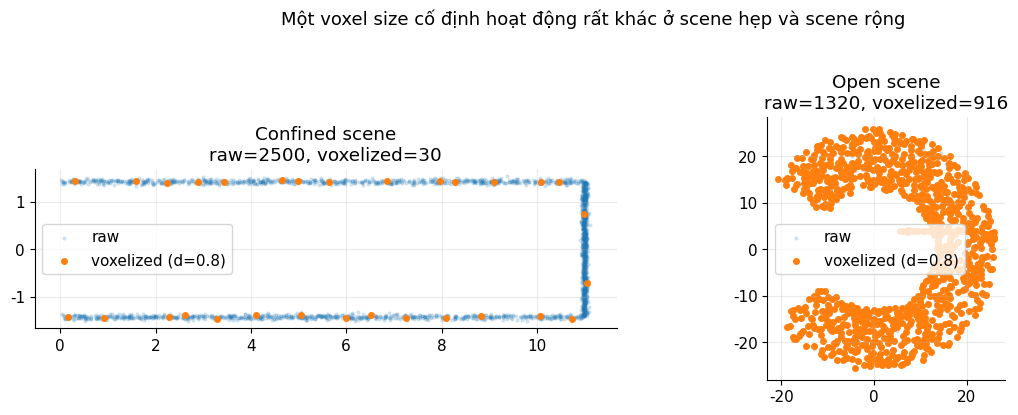

In [2]:
# Demo 1: cùng một voxel size nhưng áp vào "scene hẹp" và "scene rộng" sẽ cho hiệu ứng rất khác.

narrow_scene = make_scaled_scene(scale=7, n=2500, seed=1)
open_scene   = make_scaled_scene(scale=26, n=1200, seed=2)

voxel_size = 0.8
narrow_vox = voxelize_2d(narrow_scene, voxel_size)
open_vox   = voxelize_2d(open_scene, voxel_size)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(narrow_scene[:, 0], narrow_scene[:, 1], s=4, alpha=0.15, label="raw")
axes[0].scatter(narrow_vox[:, 0], narrow_vox[:, 1], s=16, label=f"voxelized (d={voxel_size})")
axes[0].set_title(f"Confined scene\nraw={len(narrow_scene)}, voxelized={len(narrow_vox)}")
axes[0].set_aspect("equal")
axes[0].legend()

axes[1].scatter(open_scene[:, 0], open_scene[:, 1], s=4, alpha=0.15, label="raw")
axes[1].scatter(open_vox[:, 0], open_vox[:, 1], s=16, label=f"voxelized (d={voxel_size})")
axes[1].set_title(f"Open scene\nraw={len(open_scene)}, voxelized={len(open_vox)}")
axes[1].set_aspect("equal")
axes[1].legend()

plt.suptitle("Một voxel size cố định hoạt động rất khác ở scene hẹp và scene rộng", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

### Nhìn hình trên nên rút ra điều gì?
- Ở **scene hẹp**, cùng voxel size đó có thể làm số điểm sau voxelization xuống quá thấp.
- Ở **scene rộng**, số điểm vẫn rất lớn, kéo theo chi phí tính toán cao.

Đó chính là động lực cho **adaptive voxelization** trong GenZ-LIO.

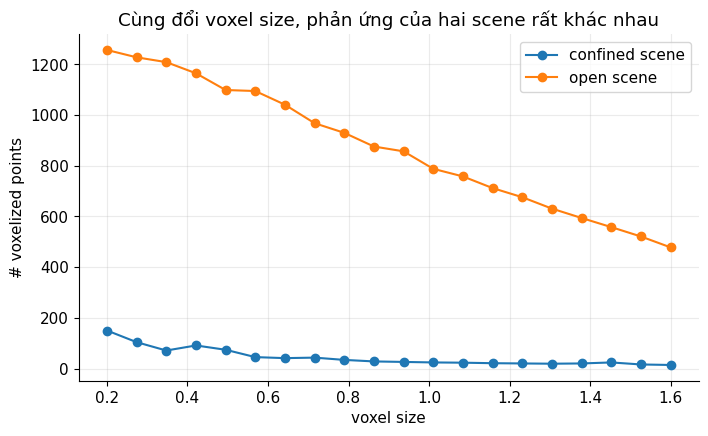

In [3]:
# Demo 2: số điểm sau voxelization thay đổi theo voxel size rất khác nhau giữa cảnh hẹp và cảnh rộng

voxel_sizes = np.linspace(0.2, 1.6, 20)
narrow_counts = [len(voxelize_2d(narrow_scene, d)) for d in voxel_sizes]
open_counts   = [len(voxelize_2d(open_scene,   d)) for d in voxel_sizes]

plt.figure(figsize=(8, 4.5))
plt.plot(voxel_sizes, narrow_counts, marker="o", label="confined scene")
plt.plot(voxel_sizes, open_counts, marker="o", label="open scene")
plt.xlabel("voxel size")
plt.ylabel("# voxelized points")
plt.title("Cùng đổi voxel size, phản ứng của hai scene rất khác nhau")
plt.legend()
plt.show()

## 3) Related work của paper — và GenZ-LIO đứng ở đâu?

Paper tách phần liên quan thành 2 nhánh chính:
1. **Adaptive voxelization**
2. **Residual metric cho scan-to-map alignment**

In [4]:
adaptive_methods = pd.DataFrame([
    ["Uniform voxel grid", "voxel size cố định", "đơn giản, nhanh", "rất nhạy với scene scale"],
    ["LOCUS 2.0", "điều chỉnh để giữ point count cố định", "tracking count ổn", "setpoint cố định"],
    ["AdaLIO", "switch coarse/fine", "đơn giản, hữu ích khi vào chỗ hẹp", "chỉ có 2 mức rời rạc"],
    ["LIVOX-CAM", "temp voxelization + volume-based scaling", "thích nghi tốt hơn fixed-size", "vẫn bám point count cố định"],
    ["GenZ-LIO", "scene-scale-informed setpoint + PD + gain scheduling", "liên tục, ổn định, có awareness theo scale", "phức tạp hơn một chút"],
], columns=["Method", "How it adapts", "Strength", "Limitation / paper's view"])

metric_methods = pd.DataFrame([
    ["Point-to-plane", "mạnh khi mặt phẳng rõ, normals đáng tin", "dễ yếu khi normals kém / dữ liệu thưa"],
    ["Point-to-point", "không cần normals, hữu ích ở vùng ít planar structure", "không tận dụng tốt planar structure mạnh"],
    ["G-ICP / plane-like methods", "rất mạnh ở nhiều cảnh chuẩn", "vẫn dựa vào giả định local plane"],
    ["Hybrid metric", "kết hợp ưu điểm của 2 metric", "cần weighting và search hợp lý"],
], columns=["Metric family", "When it helps", "When it may struggle"])

display(adaptive_methods)
display(metric_methods)

,Method,How it adapts,Strength,Limitation / paper's view
0,Uniform voxel grid,voxel size cố định,"đơn giản, nhanh",rất nhạy với scene scale
1,LOCUS 2.0,điều chỉnh để giữ point count cố định,tracking count ổn,setpoint cố định
2,AdaLIO,switch coarse/fine,"đơn giản, hữu ích khi vào chỗ hẹp",chỉ có 2 mức rời rạc
3,LIVOX-CAM,temp voxelization + volume-based scaling,thích nghi tốt hơn fixed-size,vẫn bám point count cố định
4,GenZ-LIO,scene-scale-informed setpoint + PD + gain sche...,"liên tục, ổn định, có awareness theo scale",phức tạp hơn một chút


,Metric family,When it helps,When it may struggle
0,Point-to-plane,"mạnh khi mặt phẳng rõ, normals đáng tin",dễ yếu khi normals kém / dữ liệu thưa
1,Point-to-point,"không cần normals, hữu ích ở vùng ít planar st...",không tận dụng tốt planar structure mạnh
2,G-ICP / plane-like methods,rất mạnh ở nhiều cảnh chuẩn,vẫn dựa vào giả định local plane
3,Hybrid metric,kết hợp ưu điểm của 2 metric,cần weighting và search hợp lý


## 4) Toàn cảnh hệ GenZ-LIO

Về mặt ý tưởng, bạn có thể nhớ bằng sơ đồ 4 khối dưới đây:

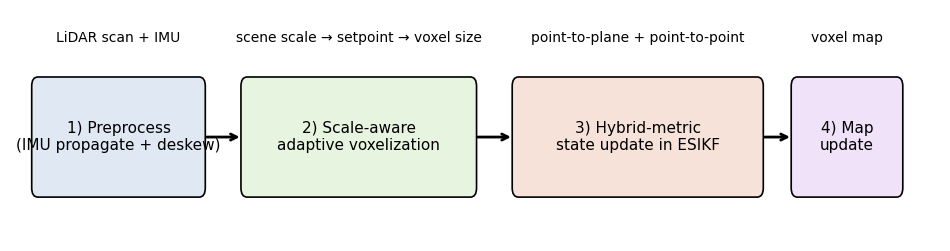

In [5]:
draw_system_overview()

### Diễn giải sơ đồ
1. **Preprocess**
   - IMU forward propagation để có prior.
   - Backward propagation để **deskew** scan LiDAR.

2. **Scale-aware adaptive voxelization**
   - Tính **scale indicator** từ scan hiện tại.
   - Suy ra **setpoint** là số điểm mong muốn sau voxelization.
   - Dùng **PD control + gain scheduling** để cập nhật voxel size.

3. **Hybrid-metric state update**
   - Lấy correspondence từ voxel map.
   - Kết hợp residual **point-to-plane** và **point-to-point**.

4. **Map update**
   - Scan đã căn chỉnh được đưa vào voxel map.

# Phần I — Scale-aware adaptive voxelization

Đây là module đầu tiên và là phần rất “điều khiển học” của paper.

## Ý tưởng cốt lõi
Thay vì dùng một voxel size cố định, GenZ-LIO làm 3 việc:

1. Ước lượng xem cảnh hiện tại đang **hẹp hay rộng**.
2. Từ đó quyết định số điểm sau voxelization **nên là bao nhiêu**.
3. Điều khiển voxel size để point count tiến gần số điểm mong muốn đó.

Paper mô tả phần này ở **Sec. IV**.

## 5) Scale indicator: vì sao paper dùng median range + moving average?

Paper làm như sau:

1. Voxelize tạm thời scan bằng voxel size của bước trước: thu được \(V_{\text{temp},t}\).
2. Tính range của từng điểm trong scan tạm đó.
3. Lấy **median** của các range → \(m_t\).
4. Lấy **moving average** trên cửa sổ trượt → \(\bar m_t\).

### Tại sao không lấy mean?
Vì LiDAR có thể có vài điểm rất xa hoặc outlier. **Median** ổn định hơn **mean**.

### Tại sao còn phải smoothing?
Vì nếu dùng ngay \(m_t\), voxel size sẽ phản ứng quá gắt với dao động scan-level.

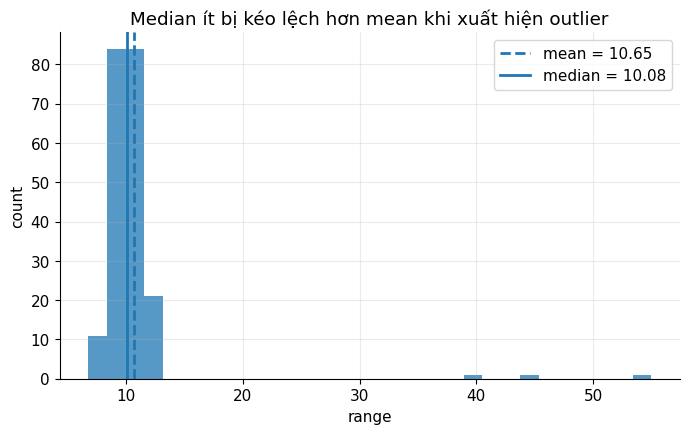

Clean data      -> mean=10.11, median=10.07
With outliers   -> mean=10.65, median=10.08


In [6]:
# Demo 3: median ổn hơn mean khi có outlier range

rng = np.random.default_rng(123)
ranges_clean = rng.normal(loc=10.0, scale=1.2, size=200)
ranges_with_outliers = np.concatenate([ranges_clean, np.array([40, 45, 55])])

mean_clean = ranges_clean.mean()
median_clean = np.median(ranges_clean)
mean_out = ranges_with_outliers.mean()
median_out = np.median(ranges_with_outliers)

plt.figure(figsize=(8, 4.5))
plt.hist(ranges_with_outliers, bins=30, alpha=0.75)
plt.axvline(mean_out,   linestyle="--", linewidth=2, label=f"mean = {mean_out:.2f}")
plt.axvline(median_out, linestyle="-",  linewidth=2, label=f"median = {median_out:.2f}")
plt.xlabel("range")
plt.ylabel("count")
plt.title("Median ít bị kéo lệch hơn mean khi xuất hiện outlier")
plt.legend()
plt.show()

print(f"Clean data      -> mean={mean_clean:.2f}, median={median_clean:.2f}")
print(f"With outliers   -> mean={mean_out:.2f}, median={median_out:.2f}")

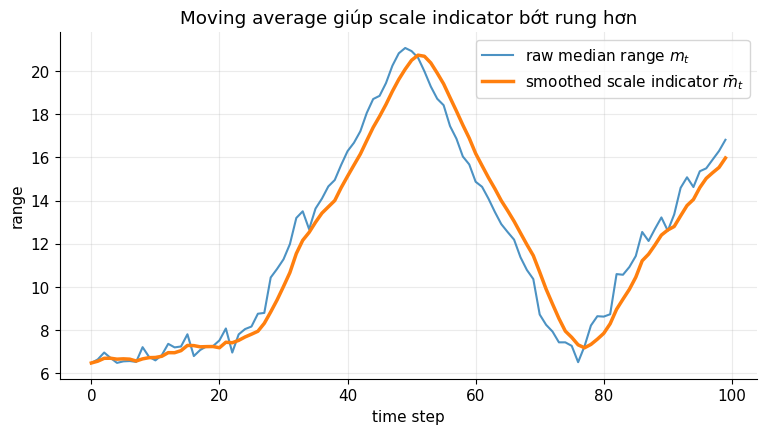

In [7]:
# Demo 4: scale indicator được làm mượt bằng moving average

scales_seq = np.concatenate([
    np.linspace(7, 10, 25),
    np.linspace(10, 28, 25),
    np.linspace(28, 8, 25),
    np.linspace(8, 22, 25),
])

m_t = []
for t, s in enumerate(scales_seq):
    pts = make_scaled_scene(s, seed=100 + t)
    vtemp = voxelize_2d(pts, 0.8)
    m_t.append(np.median(np.linalg.norm(vtemp, axis=1)))
m_t = np.array(m_t)
m_bar = moving_average(m_t, 5)

plt.figure(figsize=(9, 4.5))
plt.plot(m_t, label="raw median range $m_t$", alpha=0.8)
plt.plot(m_bar, linewidth=2.5, label="smoothed scale indicator $\\bar m_t$")
plt.xlabel("time step")
plt.ylabel("range")
plt.title("Moving average giúp scale indicator bớt rung hơn")
plt.legend()
plt.show()

## 6) Setpoint: scene rộng thì nên giữ nhiều điểm hơn

Paper định nghĩa setpoint \(N_{\text{desired},t}\) như sau:

\[
N_{\text{desired},t} =
\begin{cases}
N_{\min} + (N_{\max} - N_{\min})\,\rho(\bar m_t), & \bar m_t < \tau_m \\
N_{\max}, & \text{otherwise}
\end{cases}
\]

với

\[
\rho(\bar m_t)= 1 - \left(1 - \frac{\bar m_t}{\tau_m}\right)^p,\quad p>1
\]

## Trực giác
- \(\bar m_t\) nhỏ → cảnh hẹp → không cần quá nhiều điểm.
- \(\bar m_t\) lớn → cảnh rộng → nên giữ nhiều điểm hơn.
- Hàm saturating giúp setpoint tăng **mượt**, không gãy khúc quá mạnh.

> Trong paper, phần này nằm ở **Sec. IV-C**, công thức (1)–(2).

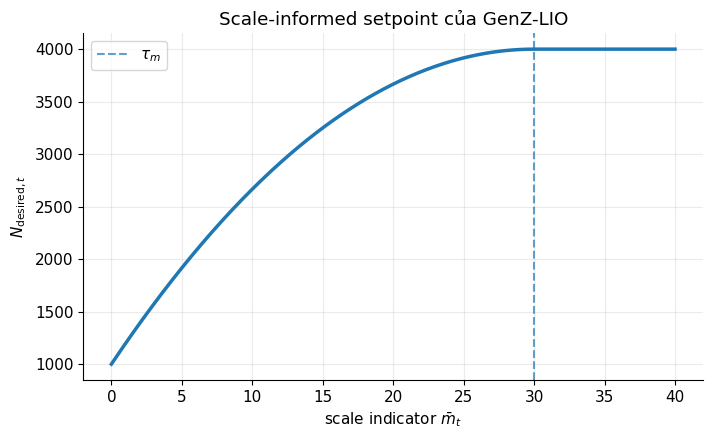

In [8]:
# Demo 5: vẽ setpoint theo scale indicator

Nmin, Nmax, tau_m, p = 1000, 4000, 30.0, 2.0
m = np.linspace(0, 40, 400)
rho = np.where(m < tau_m, 1 - (1 - m / tau_m)**p, 1.0)
Ndesired = np.where(m < tau_m, Nmin + (Nmax - Nmin) * rho, Nmax)

plt.figure(figsize=(8, 4.5))
plt.plot(m, Ndesired, linewidth=2.5)
plt.axvline(tau_m, linestyle="--", alpha=0.7, label=r"$\tau_m$")
plt.xlabel(r"scale indicator $\bar m_t$")
plt.ylabel(r"$N_{\mathrm{desired}, t}$")
plt.title("Scale-informed setpoint của GenZ-LIO")
plt.legend()
plt.show()

## 7) Tracking error và vì sao paper chọn PD thay vì PID?

Paper định nghĩa:

\[
e_t = N_{\text{desired},t} - N_{\text{temp},t}
\]

\[
\Delta e_t = \frac{e_t - e_{t-1}}{\Delta t_{\text{scan}}}
\]

Trong đó:
- \(N_{\text{temp},t}\) là số điểm thu được sau **temporary voxelization** bằng voxel size trước đó.
- \(e_t\) cho biết ta đang thiếu hay thừa bao nhiêu điểm so với setpoint.
- \(\Delta e_t\) cho biết lỗi đang đổi nhanh hay chậm.

Trong bài toán này, **setpoint thay đổi theo scene scale** chứ không cố định.  
Nếu vẫn giữ integral term, lỗi cũ có thể tích luỹ sai ngữ cảnh, gây:
- overshoot,
- dao động,
- chậm ổn định.

Vì vậy paper chọn **PD control** để phản ứng nhanh nhưng ít “ôm nợ lỗi cũ” hơn.

## 8) Gain scheduling: đây là phần “hay” nhất của module voxelization

Paper nói rằng độ nhạy giữa **voxel size** và **point count** là **phi tuyến** và thay đổi theo cảnh:

- **Cảnh hẹp, dày điểm**  
  point count rất nhạy với thay đổi voxel size  
  → gain quá cao sẽ làm hệ rung/dao động.

- **Cảnh rộng, thưa hơn**  
  point count kém nhạy hơn  
  → cần gain cao hơn để tracking đủ nhanh.

Ngoài scene scale, paper còn dùng:
- độ lớn lỗi \(|e_t|\) cho \(K_p\),
- độ lớn đạo hàm lỗi \(|\Delta e_t|\) cho \(K_d\).

Các biến chuẩn hoá:

\[
\phi_t = \frac{\min(\bar m_t,\tau_m)}{\tau_m}
\]

\[
\psi_{p,t} = \frac{\min(|e_t|,\lambda_p N_{\text{desired},t})}{\lambda_p N_{\text{desired},t}}
,\qquad
\psi_{d,t} = \frac{\min(|\Delta e_t|,\lambda_d N_{\text{desired},t}/\Delta t_{\text{scan}})}{\lambda_d N_{\text{desired},t}/\Delta t_{\text{scan}}}
\]

Sau đó:

\[
\Gamma_{p,t} = \sqrt{\phi_t \psi_{p,t}},\qquad
\Gamma_{d,t} = \sqrt{\phi_t \psi_{d,t}}
\]

\[
K_{p,t} = K_{p,\min} + (K_{p,\max} - K_{p,\min}) \Gamma_{p,t}
\]

\[
K_{d,t} = K_{d,\min} + (K_{d,\max} - K_{d,\min}) \Gamma_{d,t}
\]

### Trực giác của geometric mean
Nếu chỉ dùng scene scale **hoặc** chỉ dùng error magnitude thì đều cực đoan.  
Geometric mean giúp gain “cân bằng” giữa:
- độ nhạy của cảnh,
- mức độ cần phản ứng mạnh.

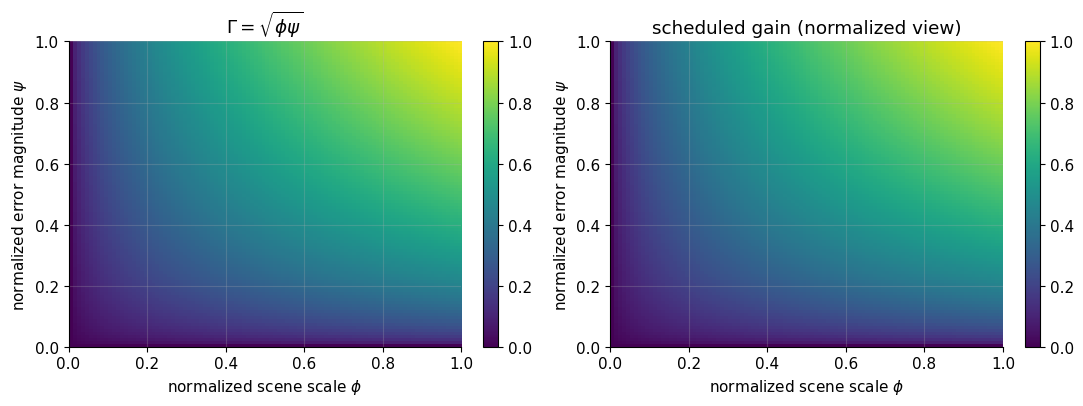

In [9]:
# Demo 6: heatmap của gain scheduling
# Ta chỉ vẽ trực giác của Gamma = sqrt(phi * psi)

phi = np.linspace(0, 1, 100)
psi = np.linspace(0, 1, 100)
PHI, PSI = np.meshgrid(phi, psi)

Gamma = np.sqrt(PHI * PSI)
Kp = Gamma

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
im0 = ax[0].imshow(Gamma, origin="lower", extent=[0, 1, 0, 1], aspect="auto")
ax[0].set_xlabel("normalized scene scale $\\phi$")
ax[0].set_ylabel("normalized error magnitude $\\psi$")
ax[0].set_title(r"$\Gamma = \sqrt{\phi \psi}$")
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(Kp, origin="lower", extent=[0, 1, 0, 1], aspect="auto")
ax[1].set_xlabel("normalized scene scale $\\phi$")
ax[1].set_ylabel("normalized error magnitude $\\psi$")
ax[1].set_title("scheduled gain (normalized view)")
plt.colorbar(im1, ax=ax[1], fraction=0.046)

plt.tight_layout()
plt.show()

## 9) Voxel size update và bi-resolution voxelization

Sau khi có \(K_{p,t}\) và \(K_{d,t}\), paper cập nhật voxel size bằng:

\[
\Delta d_t = -K_{p,t} e_t - K_{d,t} \Delta e_t
\]

\[
d_t = \mathrm{clamp}(d_{t-1} + \Delta d_t,\ d_{\min}, d_{\max})
\]

Dấu âm xuất hiện vì:
- nếu ta **thiếu điểm** (\(e_t > 0\)),
- ta phải **giảm voxel size**,
- để giữ lại nhiều điểm hơn.

### Bi-resolution voxelization
Paper không dùng một voxelized scan duy nhất, mà dùng 2 mức:
- \(V_{\text{merge},t}\): voxelize bằng \(d_t/2\) → dày hơn, tốt cho map update.
- \(V_t\): voxelize lại bằng \(d_t\) → gọn hơn, tốt cho state update.

Ý tưởng:
- update state thì muốn **gọn**;
- update map thì muốn **đỡ lỗi rời rạc hơn**.

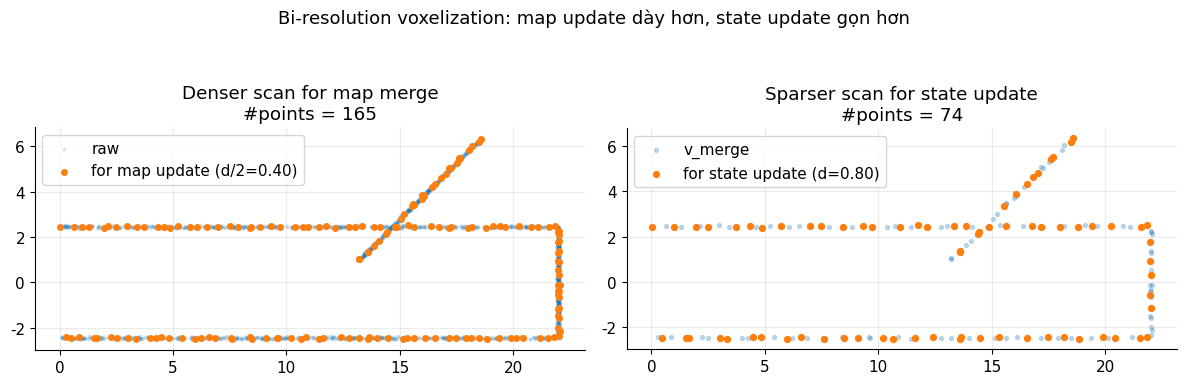

In [10]:
# Demo 7: bi-resolution voxelization trên cùng một scan

scene = make_scaled_scene(scale=18, seed=21)
d = 0.8
v_merge = voxelize_2d(scene, d / 2)
v_state = voxelize_2d(v_merge, d)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(scene[:, 0], scene[:, 1], s=4, alpha=0.12, label="raw")
axes[0].scatter(v_merge[:, 0], v_merge[:, 1], s=16, label=f"for map update (d/2={d/2:.2f})")
axes[0].set_title(f"Denser scan for map merge\n#points = {len(v_merge)}")
axes[0].set_aspect("equal")
axes[0].legend()

axes[1].scatter(v_merge[:, 0], v_merge[:, 1], s=8, alpha=0.25, label="v_merge")
axes[1].scatter(v_state[:, 0], v_state[:, 1], s=18, label=f"for state update (d={d:.2f})")
axes[1].set_title(f"Sparser scan for state update\n#points = {len(v_state)}")
axes[1].set_aspect("equal")
axes[1].legend()

plt.suptitle("Bi-resolution voxelization: map update dày hơn, state update gọn hơn", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

### Chốt phần adaptive voxelization bằng 1 câu
GenZ-LIO không hỏi: **“ta đang dùng voxel size nào?”**  
Nó hỏi: **“với cảnh hiện tại, ta nên giữ bao nhiêu điểm — và phải chỉnh voxel size thế nào để đạt con số đó một cách ổn định?”**

# Phần II — Hybrid-metric state update trong ESIKF

Đây là module thứ hai.

## Tư tưởng
Đừng cố sống chết dùng một residual metric cho mọi cảnh.

- Nơi có planar structure tốt → **point-to-plane** rất mạnh.
- Nơi normals kém hoặc ít planar structure → **point-to-point** hữu ích hơn.

GenZ-LIO ghép cả hai vào một bước update chung trong **Error-State Iterated Kalman Filter (ESIKF)**.

## 10) Trực giác EKF / ESIKF bằng ví dụ 1D

Trước khi đụng ma trận 18 chiều, hãy nhớ trực giác của Kalman:

- **Prior**: IMU nói “tôi tin vị trí hiện tại khoảng đây”.
- **Measurement**: LiDAR nói “không, scan-to-map alignment gợi ý nên ở chỗ khác”.
- **Posterior**: trộn hai nguồn theo **độ bất định**.

ESIKF chỉ là một phiên bản:
- làm việc trên **error-state**,
- và **iterate** nhiều lần để tuyến tính hoá tốt hơn.

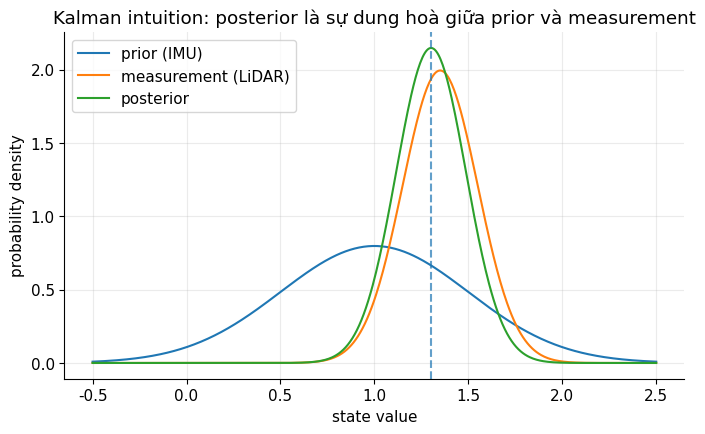

Posterior mean = 1.302, posterior std = 0.186


In [11]:
# Demo 8: 1D Kalman fusion trực giác

mu_prior, sigma_prior = 1.0, 0.50
mu_meas,  sigma_meas  = 1.35, 0.20

var_post = 1.0 / (1.0 / sigma_prior**2 + 1.0 / sigma_meas**2)
mu_post = var_post * (mu_prior / sigma_prior**2 + mu_meas / sigma_meas**2)
sigma_post = np.sqrt(var_post)

x = np.linspace(-0.5, 2.5, 500)
plt.figure(figsize=(8, 4.5))
plt.plot(x, gaussian_pdf(x, mu_prior, sigma_prior), label="prior (IMU)")
plt.plot(x, gaussian_pdf(x, mu_meas, sigma_meas), label="measurement (LiDAR)")
plt.plot(x, gaussian_pdf(x, mu_post, sigma_post), label="posterior")
plt.axvline(mu_post, linestyle="--", alpha=0.7)
plt.title("Kalman intuition: posterior là sự dung hoà giữa prior và measurement")
plt.xlabel("state value")
plt.ylabel("probability density")
plt.legend()
plt.show()

print(f"Posterior mean = {mu_post:.3f}, posterior std = {sigma_post:.3f}")

## 11) State vector của paper có gì?

Paper dùng một state trên manifold:

\[
\mathcal M = SO(3) \times \mathbb R^{15}
\]

Trực giác: trạng thái gồm
- vị trí,
- attitude,
- vận tốc,
- bias gyro,
- bias accel,
- gravity.

Bạn **không cần** nhớ toàn bộ ký hiệu để hiểu ý tưởng của paper.  
Điều quan trọng là:

1. **Prediction** dùng IMU để suy diễn state và covariance.
2. **Correction** dùng residual LiDAR để sửa lại.

Paper viết rất kỹ phần này ở **Sec. V-A**.

## 12) Point-to-plane và point-to-point khác nhau ở đâu?

### Point-to-plane
Residual dạng:
\[
r_{pl} = \mathbf n^\top (\mathbf p - \mathbf q)
\]

Tức là:
- lấy điểm hiện tại,
- đo khoảng cách theo pháp tuyến tới mặt phẳng.

**Mạnh khi**
- bề mặt thật sự planar,
- normal được ước lượng tin cậy.

### Point-to-point
Residual dạng ý tưởng:
\[
r_{po} = \lVert \mathbf p - \mathbf p' \rVert
\]

Tức là:
- lấy điểm hiện tại,
- đo khoảng cách đến điểm gần nhất.

**Mạnh khi**
- normals không đáng tin,
- dữ liệu thưa / không quá planar.

### Điểm tinh tế của paper
Paper dùng point-to-point ở dạng **scalar L2 norm residual**, không phải full vector residual 3D như vài biến thể ICP.  
Lý do:
- giảm chi phí tính toán,
- cân bằng tốt hơn khi ghép với point-to-plane scalar residual.

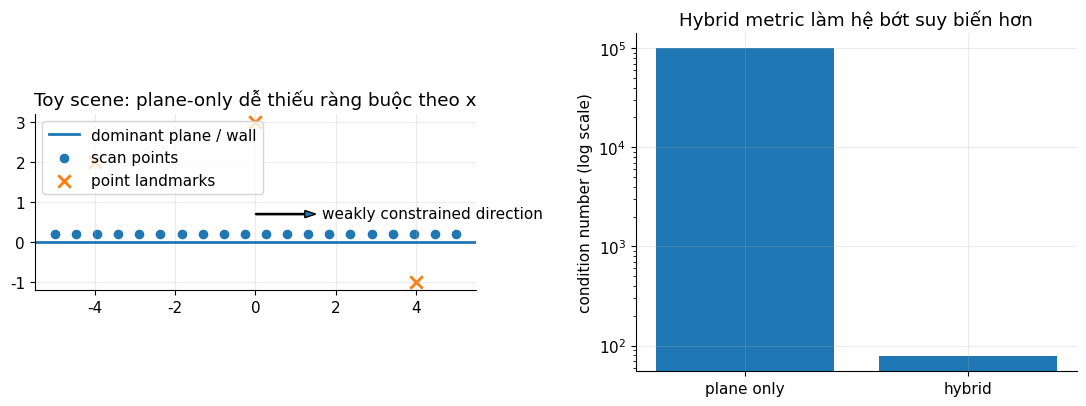

Condition number (plane only) = infinite / singular
Condition number (hybrid)     = 78.605


In [12]:
# Demo 9: minh hoạ degeneracy bằng bài toán 2D rất đơn giản

# Ta giả sử robot đang thấy chủ yếu một "bức tường ngang" (normal theo trục y).
# Point-to-line residual loại này gần như không khoá tốt tịnh tiến theo x.
# Nếu thêm vài point-to-point constraints ở landmark rời rạc, bài toán sẽ đủ ràng buộc hơn.

xs = np.linspace(-5, 5, 20)
scan_points = np.column_stack([xs, np.full_like(xs, 0.2)])

H_plane = np.vstack([line_jacobian_2d(p) for p in scan_points])
G_plane = H_plane.T @ H_plane

landmarks = np.array([[-4, 2], [0, 3], [4, -1]])
H_point = np.vstack([point_jacobian_vec_2d(p) for p in landmarks])
G_hybrid = G_plane + H_point.T @ H_point

cond_plane = np.inf if np.linalg.matrix_rank(G_plane) < 3 else np.linalg.cond(G_plane)
cond_hybrid = np.linalg.cond(G_hybrid)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].axhline(0, linewidth=2, label="dominant plane / wall")
axes[0].scatter(scan_points[:, 0], scan_points[:, 1], s=35, label="scan points")
axes[0].scatter(landmarks[:, 0], landmarks[:, 1], s=80, marker="x", linewidths=2, label="point landmarks")
axes[0].arrow(0, 0.7, 1.5, 0, width=0.03, head_width=0.18, length_includes_head=True)
axes[0].text(1.65, 0.72, "weakly constrained direction", va="center")
axes[0].set_aspect("equal")
axes[0].set_title("Toy scene: plane-only dễ thiếu ràng buộc theo x")
axes[0].legend(loc="upper left")

cond_vis = [1e5 if np.isinf(cond_plane) else cond_plane, cond_hybrid]
axes[1].bar(["plane only", "hybrid"], cond_vis)
axes[1].set_yscale("log")
axes[1].set_ylabel("condition number (log scale)")
axes[1].set_title("Hybrid metric làm hệ bớt suy biến hơn")

plt.tight_layout()
plt.show()

print("Condition number (plane only) =", "infinite / singular" if np.isinf(cond_plane) else f"{cond_plane:.3f}")
print(f"Condition number (hybrid)     = {cond_hybrid:.3f}")

### Ý nghĩa của demo trên
- Với **point-to-plane** kiểu “chỉ thấy một tường ngang”, bài toán gần như không biết phải sửa **tịnh tiến theo x** thế nào.
- Khi thêm vài **point-to-point** correspondence ở vị trí rời rạc, bài toán có thêm ràng buộc theo các hướng đang thiếu.

Đó chính là tinh thần ở **Sec. V-E** và cũng là điều paper chứng minh bằng **condition number** trong phần thực nghiệm.

## 13) Covariance và weighting: paper không cộng residual một cách “ngang hàng”

Một điểm rất hay là paper không cho tất cả correspondence trọng số như nhau.

### Với point-to-plane
Paper dùng covariance sinh ra từ bất định của:
- normal,
- centroid / plane center,
- query point.

### Với point-to-point
Paper dùng covariance sinh ra từ bất định của:
- query point,
- target point gần nhất,

rồi cộng thêm một thành phần **discretization error**:

\[
R_{\text{disc}} = \frac{N_{\text{accessed}} \cdot d_{\text{root}}^2}{N_{\text{eval}}}
\]

Trực giác:
- nếu phải truy cập nhiều voxel,
- nhưng chỉ đánh giá được ít điểm hữu ích,
- thì correspondence đó mang nhiều bất định do rời rạc hoá hơn.

Sau đó paper dùng:

\[
R^{\text{comb}}_{po} = \lambda_{po}\left(R^{\text{norm}}_{po} + R_{\text{disc}}\right)
\]

để cân bằng point-to-point với point-to-plane.

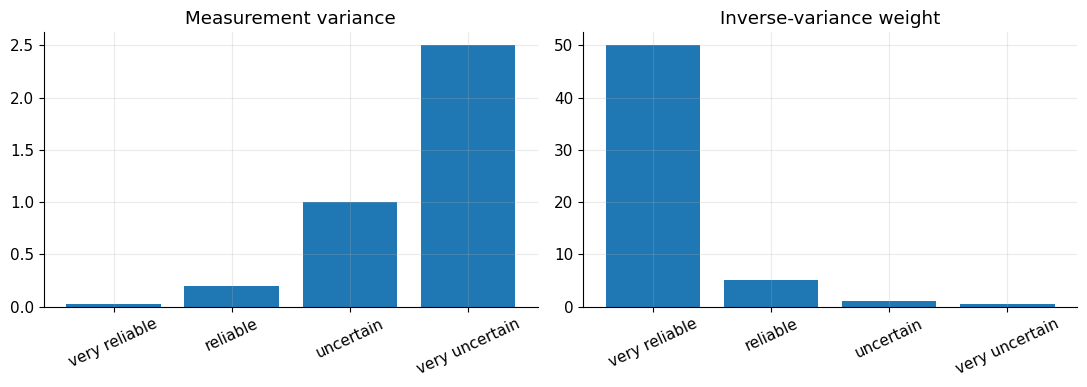

In [13]:
# Demo 10a: uncertainty lớn -> weight nhỏ hơn

variances = np.array([0.02, 0.20, 1.00, 2.50])
weights = 1.0 / variances
labels = ["very reliable", "reliable", "uncertain", "very uncertain"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(labels, variances)
axes[0].set_title("Measurement variance")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(labels, weights)
axes[1].set_title("Inverse-variance weight")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

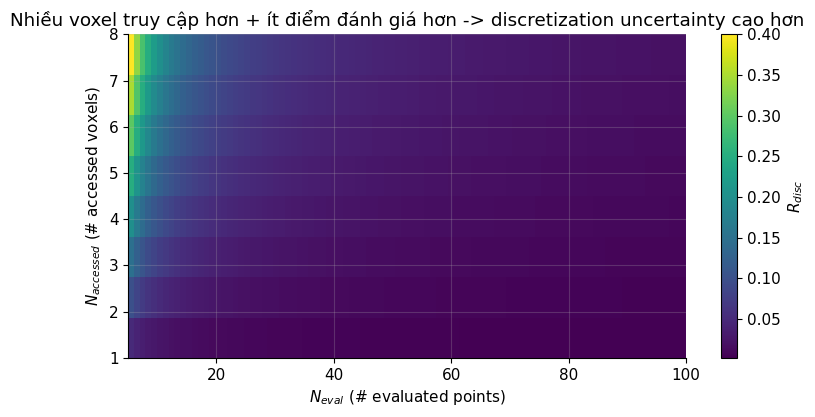

In [14]:
# Demo 10b: heatmap của discretization error R_disc = N_accessed * d_root^2 / N_eval

d_root = 0.5
N_accessed = np.arange(1, 9)
N_eval = np.arange(5, 101)

R_disc = np.array([[na * d_root**2 / ne for ne in N_eval] for na in N_accessed])

plt.figure(figsize=(9, 4.2))
plt.imshow(R_disc, origin="lower", aspect="auto",
           extent=[N_eval.min(), N_eval.max(), N_accessed.min(), N_accessed.max()])
plt.colorbar(label=r"$R_{disc}$")
plt.xlabel(r"$N_{eval}$ (# evaluated points)")
plt.ylabel(r"$N_{accessed}$ (# accessed voxels)")
plt.title("Nhiều voxel truy cập hơn + ít điểm đánh giá hơn -> discretization uncertainty cao hơn")
plt.show()

# Phần III — Voxel-pruned correspondence search

Đây là module thứ ba.

## Bài toán
Point-to-point matching thường đắt vì:
- mỗi voxel có thể chứa nhiều điểm tích luỹ từ map,
- mỗi query point có thể phải kiểm tra rất nhiều voxel lân cận,
- trong mỗi voxel lại phải tính nhiều khoảng cách.

Paper giải quyết bằng **hai tầng cắt tỉa**:

1. **Candidate voxel selection**  
   Không phải lúc nào cũng phải duyệt hết 26 voxel lân cận.

2. **Lower-bound pruning**  
   Nếu khoảng cách thấp nhất có thể từ query point đến voxel đó còn lớn hơn best hiện tại, thì bỏ qua voxel đó luôn.

## 14) Candidate voxel selection — giải thích bằng bản 2D rút gọn

Trong paper 3D:
- root voxel được chia thành **27 vùng con**,
- query point nằm ở vùng nào thì chỉ một số voxel lân cận mới là “ứng viên hợp lý”.

Để dễ hiểu, ta vẽ bản **2D tương tự**:
- root cell chia thành **9 vùng con**,
- query ở **giữa** → gần như chỉ cần cell gốc,
- query ở **mép** → thêm một cell kề mép,
- query ở **góc** → thêm các cell chạm góc đó.

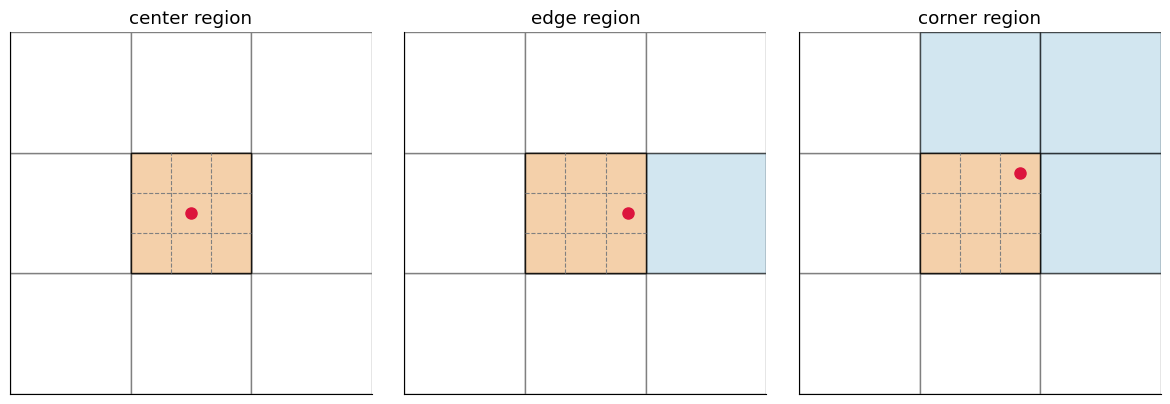

In [15]:
draw_candidate_selection_2d()

## 15) Lower-bound pruning — nếu một voxel không thể cho điểm gần hơn, đừng mở nó ra

Paper định nghĩa một khoảng cách kiểu **lower bound** từ query point đến voxel lân cận:
- point-to-surface,
- point-to-edge,
- point-to-corner,

tuỳ quan hệ hình học.

Nếu lower bound này đã lớn hơn **best distance hiện tại**, thì mọi điểm trong voxel đó cũng không thể thắng được → **skip**.

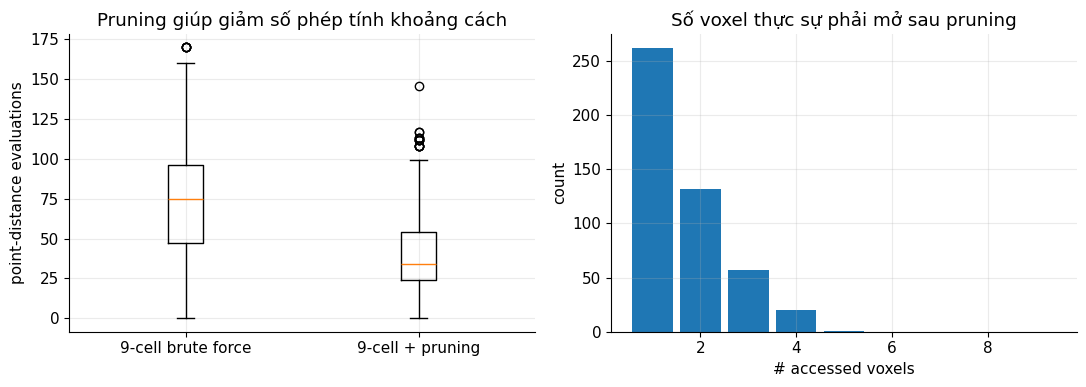

Average evaluations (brute force) = 74.43
Average evaluations (pruned)      = 39.72
Average accessed voxels (pruned)  = 1.56
Nearest-neighbor mismatch count   = 0 / 500 (should be 0 in this 9-cell toy demo)


In [16]:
# Demo 11: 2D toy search cost
# So sánh:
# - brute force trên 9 cell (root + 8 neighbors)
# - cũng trên 9 cell nhưng có lower-bound pruning
# Trong paper thật là 3D và có thêm candidate selection thông minh hơn.

cells = gen_grid_map(num_cells=20, occupancy=0.35, pts_range=(10, 40), seed=123)
rng = np.random.default_rng(456)

queries = [np.array([rng.uniform(-5, 5), rng.uniform(-5, 5)]) for _ in range(500)]

brute_evals = []
pruned_evals = []
accessed_voxels = []
mismatch = 0

for q in queries:
    d0, e0 = brute_force_search_9(cells, q)
    d1, e1, a1 = pruned_search_9(cells, q)
    brute_evals.append(e0)
    pruned_evals.append(e1)
    accessed_voxels.append(a1)
    if abs(d0 - d1) > 1e-12:
        mismatch += 1

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].boxplot([brute_evals, pruned_evals], tick_labels=["9-cell brute force", "9-cell + pruning"])
axes[0].set_ylabel("point-distance evaluations")
axes[0].set_title("Pruning giúp giảm số phép tính khoảng cách")

axes[1].hist(accessed_voxels, bins=np.arange(0.5, 10.5, 1), rwidth=0.85)
axes[1].set_xlabel("# accessed voxels")
axes[1].set_ylabel("count")
axes[1].set_title("Số voxel thực sự phải mở sau pruning")

plt.tight_layout()
plt.show()

print(f"Average evaluations (brute force) = {np.mean(brute_evals):.2f}")
print(f"Average evaluations (pruned)      = {np.mean(pruned_evals):.2f}")
print(f"Average accessed voxels (pruned)  = {np.mean(accessed_voxels):.2f}")
print(f"Nearest-neighbor mismatch count   = {mismatch} / {len(queries)} (should be 0 in this 9-cell toy demo)")

## 16) Ba thuật toán của paper — viết lại bằng ngôn ngữ dễ hiểu

### Algorithm 1 — Scale-aware adaptive voxelization
```python
Vtemp = voxelize(scan, d_prev)
Ntemp = len(Vtemp)
mt = median(range(point) for point in Vtemp)
mbar = moving_average(mt)

Ndesired = scale_to_setpoint(mbar)
e  = Ndesired - Ntemp
de = (e - e_prev) / dt_scan

Kp, Kd = schedule_gains(mbar, abs(e), abs(de))
d = clamp(d_prev - Kp * e - Kd * de, dmin, dmax)

Vmerge = voxelize(scan, d / 2)   # for map update
Vstate = voxelize(Vmerge, d)     # for state update
```

### Algorithm 2 — Point-to-point correspondence search with pruning
```python
search root voxel first
best_distance = distance_to_best_point_in_root

for each candidate neighboring voxel:
    lower_bound = distance_from_query_to_voxel_itself
    if lower_bound >= best_distance:
        skip this voxel
    else:
        search points inside this voxel
        update best_distance if needed
```

### Algorithm 3 — Hybrid-metric state update in ESIKF
```python
repeat until convergence:
    build point-to-plane correspondences
    build point-to-point correspondences
    compute residuals, Jacobians, covariances
    stack everything into one MAP / ESIKF update
    update state estimate

merge denser voxelized scan into voxel map
```

# Phần IV — Thực nghiệm của paper, đọc sao cho dễ

Paper đánh giá trên:
- **9 bộ dữ liệu public**,
- cộng thêm **NarrowWide** do tác giả thu thập để test các chuyển cảnh indoor–outdoor rất mạnh.

Các thí nghiệm chính:
1. Benchmark tổng thể.
2. So sánh adaptive voxelization với các phương pháp trước.
3. Ablation về gain scheduling.
4. Ablation về hybrid metric.
5. Ablation về voxel-pruned search.

In [17]:
dataset_df = pd.DataFrame([
    ["SubT-MRS", "Long Corridor, Laurel Cavern, Multi Floor", "indoor + transitional", "Velodyne VLP-16"],
    ["SuperLoc", "Cave 01/02/04, Corridor 02", "indoor + transitional", "Velodyne VLP-16"],
    ["2021 HILTI", "Basement 04, Drone Arena", "indoor", "Livox MID-70"],
    ["2022 HILTI", "Exp 10/16/18", "indoor with tight stairs / open halls", "Hesai PandarXT-32"],
    ["GEODE", "Stairs, Waterways, Offroad", "indoor + outdoor degenerate", "Velodyne VLP-16"],
    ["M3DGR", "Corridor 01/02, GNSS-denial 01/02", "indoor + outdoor", "Livox AVIA"],
    ["NTU-VIRAL", "SPMS 01/02/03", "high-altitude outdoor", "Ouster OS1-16"],
    ["ENWIDE", "Katzensee, Intersection", "outdoor", "Ouster OS0-128"],
    ["Oxford Spires", "christ-church, blenheim-palace", "indoor–outdoor transition", "Hesai QT64"],
    ["NarrowWide", "Tracked-01/02, Handheld-A/B", "strong indoor–outdoor transitions", "multiple sensors"],
], columns=["Dataset", "Sequences (summary)", "Scene type", "LiDAR"])

display(dataset_df)

,Dataset,Sequences (summary),Scene type,LiDAR
0,SubT-MRS,"Long Corridor, Laurel Cavern, Multi Floor",indoor + transitional,Velodyne VLP-16
1,SuperLoc,"Cave 01/02/04, Corridor 02",indoor + transitional,Velodyne VLP-16
2,2021 HILTI,"Basement 04, Drone Arena",indoor,Livox MID-70
3,2022 HILTI,Exp 10/16/18,indoor with tight stairs / open halls,Hesai PandarXT-32
4,GEODE,"Stairs, Waterways, Offroad",indoor + outdoor degenerate,Velodyne VLP-16
5,M3DGR,"Corridor 01/02, GNSS-denial 01/02",indoor + outdoor,Livox AVIA
6,NTU-VIRAL,SPMS 01/02/03,high-altitude outdoor,Ouster OS1-16
7,ENWIDE,"Katzensee, Intersection",outdoor,Ouster OS0-128
8,Oxford Spires,"christ-church, blenheim-palace",indoor–outdoor transition,Hesai QT64
9,NarrowWide,"Tracked-01/02, Handheld-A/B",strong indoor–outdoor transitions,multiple sensors


## 17) Benchmark tổng thể (Table II)

Một điểm rất đáng chú ý trong Table II:
- vài phương pháp có **ATE rất thấp** nhưng vẫn bị **diverge** ở một số sequence;
- GenZ-LIO đạt **0% divergence**, trong khi ATE tổng thể vẫn rất tốt.

> Ghi chú quan trọng của paper: **Average ATE được tính sau khi loại các case diverged**.  
> Vì vậy khi đọc ATE, phải đọc cùng divergence rate.

,Method,Total divergence rate (%),Total average ATE (m)
10,GenZ-LIO,0.00,0.75
9,Baseline + hybrid-metric,2.38,1.14
8,Baseline + adap. vox.,4.76,0.46
2,AdaLIO,7.14,7.24
3,Point-LIO,9.52,10.39
0,FAST-LIO2,16.67,8.12
1,Faster-LIO,21.43,4.26
7,PV-LIO (Baseline),23.81,1.38
6,iG-LIO,33.33,5.51
4,LIO-EKF,34.38,9.91


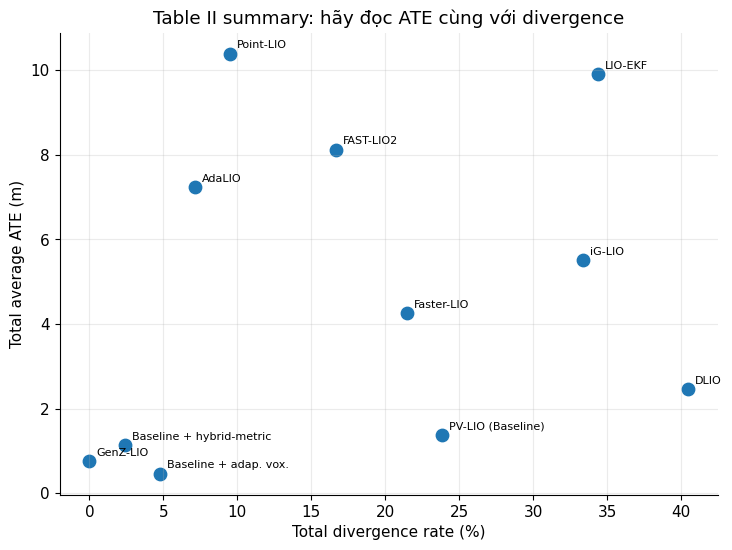

In [18]:
benchmark_df = pd.DataFrame({
    "Method": [
        "FAST-LIO2", "Faster-LIO", "AdaLIO", "Point-LIO", "LIO-EKF",
        "DLIO", "iG-LIO", "PV-LIO (Baseline)",
        "Baseline + adap. vox.", "Baseline + hybrid-metric", "GenZ-LIO"
    ],
    "Total divergence rate (%)": [16.67, 21.43, 7.14, 9.52, 34.38, 40.48, 33.33, 23.81, 4.76, 2.38, 0.00],
    "Total average ATE (m)": [8.12, 4.26, 7.24, 10.39, 9.91, 2.46, 5.51, 1.38, 0.46, 1.14, 0.75],
})

display(benchmark_df.sort_values("Total divergence rate (%)"))

plt.figure(figsize=(8.5, 6))
plt.scatter(benchmark_df["Total divergence rate (%)"], benchmark_df["Total average ATE (m)"], s=80)
for _, row in benchmark_df.iterrows():
    plt.annotate(row["Method"],
                 (row["Total divergence rate (%)"], row["Total average ATE (m)"]),
                 xytext=(5, 4), textcoords="offset points", fontsize=8)
plt.xlabel("Total divergence rate (%)")
plt.ylabel("Total average ATE (m)")
plt.title("Table II summary: hãy đọc ATE cùng với divergence")
plt.show()

### Cách đọc nhanh hình trên
- Góc **trái-dưới** là tốt nhất: **ít divergence** và **ATE thấp**.
- **Baseline + adaptive voxelization** có ATE trung bình rất thấp, nhưng vẫn chưa đạt 0% divergence.
- **GenZ-LIO** là phương án cân bằng rất tốt: **0% divergence** và ATE vẫn thấp.

## 18) So sánh adaptive voxelization (Table III)

Paper so GenZ-LIO với:
- LOCUS 2.0,
- AdaLIO,
- LIVOX-CAM,

trên cùng một baseline framework để công bằng.

Kết quả chính:
- **CPU usage thấp nhất**
- **computation time thấp nhất**
- **ATE tốt nhất** trong nhóm adaptive voxelization được so sánh

,Method,CPU mean (%),Comp. time mean (ms),RTE RMSE (cm),ATE RMSE (m)
0,Baseline,270.12,16.83,NaN,NaN
1,+ LOCUS 2.0,273.92,20.98,1.49,0.29
2,+ AdaLIO,294.57,24.14,1.56,0.34
3,+ LIVOX-CAM,245.93,19.60,1.60,0.30
4,+ Ours,212.23,16.64,1.42,0.16


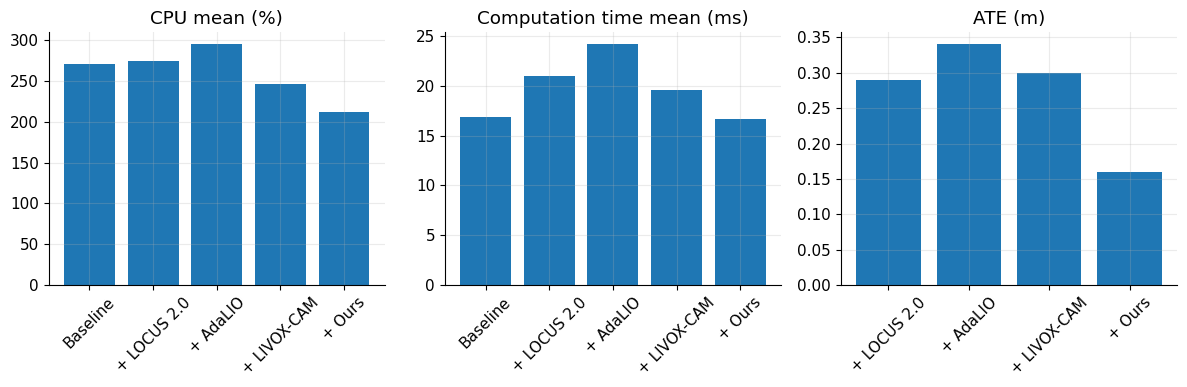

In [19]:
adaptive_comp_df = pd.DataFrame({
    "Method": ["Baseline", "+ LOCUS 2.0", "+ AdaLIO", "+ LIVOX-CAM", "+ Ours"],
    "CPU mean (%)": [270.12, 273.92, 294.57, 245.93, 212.23],
    "Comp. time mean (ms)": [16.83, 20.98, 24.14, 19.60, 16.64],
    "RTE RMSE (cm)": [np.nan, 1.49, 1.56, 1.60, 1.42],
    "ATE RMSE (m)": [np.nan, 0.29, 0.34, 0.30, 0.16],
})

display(adaptive_comp_df)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].bar(adaptive_comp_df["Method"], adaptive_comp_df["CPU mean (%)"])
axes[0].set_title("CPU mean (%)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(adaptive_comp_df["Method"], adaptive_comp_df["Comp. time mean (ms)"])
axes[1].set_title("Computation time mean (ms)")
axes[1].tick_params(axis="x", rotation=45)

subset = adaptive_comp_df.dropna()
axes[2].bar(subset["Method"], subset["ATE RMSE (m)"])
axes[2].set_title("ATE (m)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Ý nghĩa
Điểm mạnh của GenZ-LIO không chỉ là “ít lỗi hơn”, mà là:
- **giữ đủ điểm** khi vào chỗ hẹp,
- **không giữ thừa điểm** khi ra chỗ rộng,
- nên **tiết kiệm tài nguyên hơn** trong toàn bộ sequence.

## 19) Ablation về gain scheduling (Table IV)

Paper dùng 3 chỉ số:
- **IAE**: tổng sai lệch point count theo thời gian.
- **Overshoot**: phản ứng có vượt setpoint quá nhiều không.
- **ATE**: tác động xuống odometry.

Kết quả của paper:
- bỏ scale indicator đi → tracking kém hơn,
- bỏ error terms đi → tracking kém hơn,
- dùng fixed gains hoặc các chiến lược scaling cũ → kém hơn,
- bản đầy đủ của GenZ-LIO tốt nhất.

,Method,IAE (x10^3),Overshoot,ATE (m)
0,Linear scaling [3],14.03,0.24,0.21
1,Volume-based scaling [5],270.71,0.87,0.34
2,Fixed gains,53.74,1.63,0.24
3,Ours w/o scale indicator,13.32,0.16,0.19
4,Ours w/o error terms,7.95,0.15,0.21
5,Ours,6.04,0.09,0.13


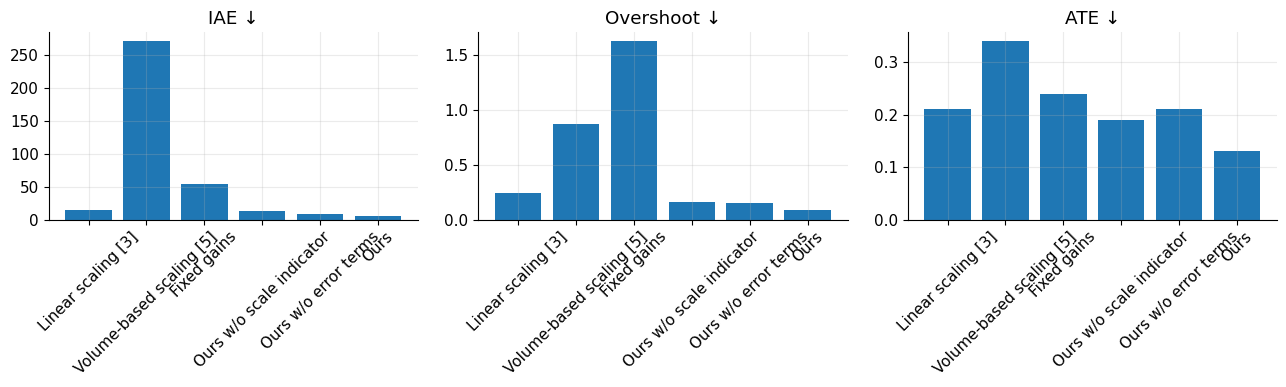

In [20]:
gain_ablation_df = pd.DataFrame({
    "Method": [
        "Linear scaling [3]",
        "Volume-based scaling [5]",
        "Fixed gains",
        "Ours w/o scale indicator",
        "Ours w/o error terms",
        "Ours",
    ],
    "IAE (x10^3)": [14.03, 270.71, 53.74, 13.32, 7.95, 6.04],
    "Overshoot": [0.24, 0.87, 1.63, 0.16, 0.15, 0.09],
    "ATE (m)": [0.21, 0.34, 0.24, 0.19, 0.21, 0.13],
})

display(gain_ablation_df)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].bar(gain_ablation_df["Method"], gain_ablation_df["IAE (x10^3)"])
axes[0].set_title("IAE ↓")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(gain_ablation_df["Method"], gain_ablation_df["Overshoot"])
axes[1].set_title("Overshoot ↓")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(gain_ablation_df["Method"], gain_ablation_df["ATE (m)"])
axes[2].set_title("ATE ↓")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Thông điệp
Gain scheduling ở đây **không phải phụ kiện**.  
Nó là chìa khoá để voxel size:
- phản ứng mạnh khi cần,
- nhưng không phá hệ ở những cảnh nhạy.

## 20) Ablation về hybrid metric (Fig. 9–10)

Paper dùng **condition number** như một chỉ số về degeneracy:
- condition number càng cao → bài toán càng khó, càng kém ổn định.

Kết quả paper cho thấy:
- baseline chỉ dùng point-to-plane → condition number cao hơn,
- thêm adaptive voxelization → khá hơn,
- thêm hybrid metric → condition number giảm mạnh nhất.

Điều này rất hợp lý:
- adaptive voxelization giúp “đủ dữ liệu” hơn,
- hybrid metric giúp “đúng loại ràng buộc” hơn.

## 21) Ablation về voxel-pruned search (Fig. 11)

Paper so 3 chiến lược search:
1. Duyệt tất cả neighbor.
2. Duyệt ít neighbor hơn.
3. Voxel-pruned correspondence search của paper.

Kết quả:
- thời gian correspondence search giảm rõ rệt,
- ATE gần như không đổi đáng kể.

Nói ngắn gọn:
> **bỏ những phép tìm kiếm chắc chắn vô ích** là một cách tăng tốc “rất sạch”.

,Framework,Search strategy,Preprocess,Correspondence,State update,Mapping,ATE
0,GenZ-LIO,26 neighbors,6.14,141.24,4.67,5.16,0.28
1,GenZ-LIO,6 neighbors,6.64,72.91,4.74,4.96,0.28
2,GenZ-LIO,Ours,7.74,48.92,6.51,5.33,0.28
3,LIO-EKF,26 neighbors,6.15,57.52,5.86,1.67,0.43
4,LIO-EKF,6 neighbors,6.63,32.97,6.12,1.70,0.39
5,LIO-EKF,Ours,6.74,25.90,6.16,1.81,0.42


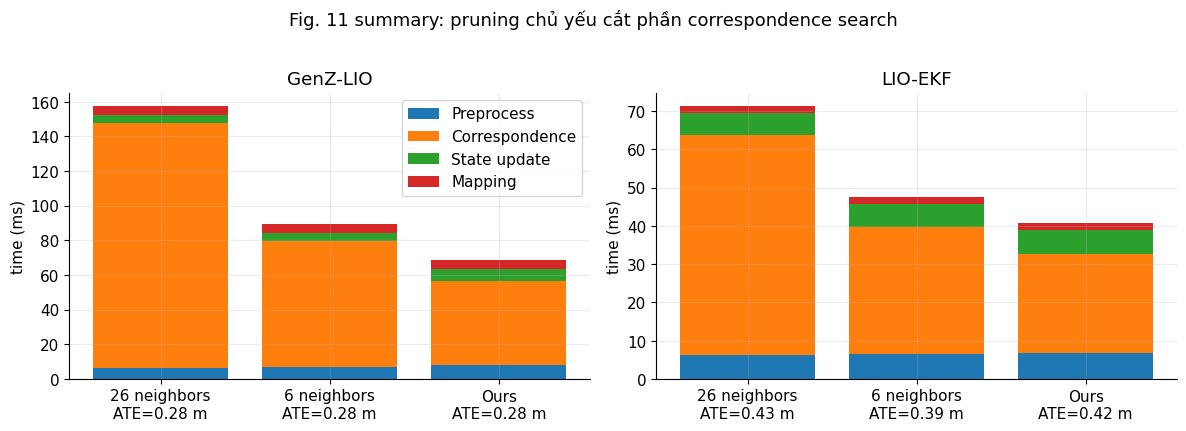

In [21]:
search_comp_df = pd.DataFrame([
    ["GenZ-LIO", "26 neighbors", 6.14, 141.24, 4.67, 5.16, 0.28],
    ["GenZ-LIO", "6 neighbors", 6.64, 72.91, 4.74, 4.96, 0.28],
    ["GenZ-LIO", "Ours", 7.74, 48.92, 6.51, 5.33, 0.28],
    ["LIO-EKF", "26 neighbors", 6.15, 57.52, 5.86, 1.67, 0.43],
    ["LIO-EKF", "6 neighbors", 6.63, 32.97, 6.12, 1.70, 0.39],
    ["LIO-EKF", "Ours", 6.74, 25.90, 6.16, 1.81, 0.42],
], columns=[
    "Framework", "Search strategy",
    "Preprocess", "Correspondence", "State update", "Mapping", "ATE"
])

display(search_comp_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=False)

for ax, framework in zip(axes, ["GenZ-LIO", "LIO-EKF"]):
    sub = search_comp_df[search_comp_df["Framework"] == framework].copy()
    x = np.arange(len(sub))
    ax.bar(x, sub["Preprocess"], label="Preprocess")
    ax.bar(x, sub["Correspondence"], bottom=sub["Preprocess"], label="Correspondence")
    ax.bar(x, sub["State update"], bottom=sub["Preprocess"] + sub["Correspondence"], label="State update")
    ax.bar(x, sub["Mapping"], bottom=sub["Preprocess"] + sub["Correspondence"] + sub["State update"], label="Mapping")

    labels = [f"{s}\nATE={a:.2f} m" for s, a in zip(sub["Search strategy"], sub["ATE"])]
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(framework)
    ax.set_ylabel("time (ms)")

axes[0].legend(loc="upper right")
plt.suptitle("Fig. 11 summary: pruning chủ yếu cắt phần correspondence search", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Phần V — Tóm tắt “đọc xong paper này thì nhớ gì?”

## 22) Một câu cho mỗi đóng góp

### (1) Scale-aware adaptive voxelization
Không dùng voxel size cố định.  
**Ước lượng scene scale → suy ra point count nên giữ → điều khiển voxel size để đạt point count đó.**

### (2) Sensitivity-informed gain scheduling
Không dùng gain cố định.  
**Gain phải phụ thuộc cả cảnh hiện tại lẫn trạng thái tracking hiện tại.**

### (3) Hybrid metric
Không đặt niềm tin tuyệt đối vào point-to-plane.  
**Cần point-to-point để vá những hướng hình học đang thiếu ràng buộc.**

### (4) Uncertainty-aware weighting
Không phải correspondence nào cũng đáng tin như nhau.  
**Residual đáng tin hơn phải được nặng hơn.**

### (5) Voxel-pruned search
Không phải neighbor nào cũng đáng để duyệt.  
**Nếu chắc chắn không thể tốt hơn best hiện tại thì bỏ luôn.**

## 23) Nếu bạn muốn tự implement một bản prototype thì nên đi theo lộ trình nào?

### Bước 1 — hiểu bản baseline
Trước tiên hãy tự hiểu hoặc cài một hệ:
- fixed voxel size,
- point-to-plane only,
- simple nearest-neighbor search.

### Bước 2 — thêm adaptive voxelization
Cài riêng module:
- temp voxelization,
- median range,
- moving average,
- scale-informed setpoint,
- PD + clamp.

### Bước 3 — thêm hybrid metric
Bắt đầu bằng một phiên bản đơn giản:
- nếu normal tốt → point-to-plane,
- nếu normal kém → point-to-point.

Sau đó mới nâng lên:
- covariance,
- balanced weighting,
- discretization error.

### Bước 4 — tối ưu correspondence search
Trước khi nghĩ tới GPU hay data structure quá nặng, hãy làm:
- search root trước,
- có lower-bound thì skip neighbor.

## 24) Những hiểu lầm dễ gặp
- “Adaptive voxelization chỉ là tuning tự động.”  
  → Không. Ở đây nó là **feedback control** bám theo setpoint phụ thuộc scene scale.

- “Hybrid metric nghĩa là lấy point-to-plane + point-to-point rồi cộng bừa.”  
  → Không. Paper có **covariance, weighting, và scalar residual design** rất rõ.

- “Pruning chỉ là mẹo nhỏ.”  
  → Không. Trong hệ thời gian thực, bỏ được khối correspondence search là rất đáng giá.

## 25) Hạn chế / điều nên nhớ
- Notebook này là **bản giảng giải**, không phải bản cài 3D đầy đủ.
- Các mô phỏng 2D ở đây nhằm truyền trực giác, không sao chép 1-1 hệ động thật của paper.
- Paper là **odometry**, không phải một hệ loop-closure / global SLAM hoàn chỉnh.

# 26) Kết luận cuối cùng

Nếu phải tóm paper này bằng một câu:

> **GenZ-LIO làm cho LIO “bớt cứng nhắc” trước thay đổi indoor–outdoor bằng cách thích nghi cả ở mức dữ liệu đầu vào (voxelization), mức residual (hybrid metric), và mức tính toán (pruned search).**

Đây là một paper rất hay để học vì nó nối được **3 thế giới**:
- robot perception,
- estimation / Kalman filtering,
- control / feedback design.

Nếu bạn đọc lại paper gốc sau notebook này, hãy tập trung vào:
- **Sec. IV** cho adaptive voxelization,
- **Sec. V** cho hybrid-metric update,
- **Sec. VI** cho cách paper tự kiểm chứng từng claim.

## Tài liệu gốc và các chỗ nên đối chiếu lại trong paper

- **Fig. 1 (trang 1)**: trajectory được tô màu theo scale indicator.
- **Fig. 2 (trang 3)**: so sánh luồng adaptive voxelization với LOCUS 2.0 / AdaLIO / LIVOX-CAM.
- **Fig. 3 (trang 4)**: system overview.
- **Sec. IV (trang 4–7)**: adaptive voxelization.
- **Sec. V (trang 7–11)**: hybrid-metric state update.
- **Table II (trang 13)**: benchmark tổng thể.
- **Table III + Fig. 7 (trang 15)**: adaptive voxelization comparison.
- **Table IV + Fig. 8 (trang 16)**: gain scheduling ablation.
- **Fig. 9–10 (trang 17)**: degeneracy và hybrid metric.
- **Fig. 11 (trang 18)**: voxel-pruned search.